Progress: [##################################################] 100.0%


 17%|██████████████████▏                                                                                          | 8/48 [00:07<00:37,  1.08it/s]

KeyboardInterrupt



In [1]:
# Handle data path
from pathlib import Path

# Read and display data from Physionet
import wfdb
import pprint
import collections
from IPython.display import clear_output

# Data manipulation and plotting
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import resample
from scipy.signal import butter,filtfilt

# Divide data into train and test set and save to HDF5
import h5py
import os
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

# Over and undersampling
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from tqdm.notebook import tqdm
import cv2
from tqdm.notebook import tqdm

In [ ]:
data_dir = Path('./data/2D_BW')
os.makedirs(data_dir, exist_ok=True)


img_dir = data_dir / 'img'
os.makedirs(img_dir, exist_ok=True)

label_dir = data_dir / 'label'
os.makedirs(label_dir, exist_ok=True)



In [ ]:
def pngConverter (destination, image_dir, if_red_dim):
    TARGET_SIZE = (112, 112)
    
    for root, dirs, files in os.walk(image_dir):
        for file in files:
            if file.endswith('.png'):
                file_path = os.path.join(root,file)
                
                img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
                
                if img is not None:
                    img_resized = cv2.resize(img, TARGET_SIZE)
                    destination.append(img_resized)
            
train_record_list = [101, 106, 108, 109, 112, 114, 115, 116, 118, 119, 122, 124, 201, 203, 205, 207, 208, 209, 215, 220, 223, 230]
test_record_list = [100, 103, 105, 111, 113, 117, 121, 123, 200, 202, 210, 212, 213,214, 219, 221, 222, 228, 231, 232, 233, 234]

In [19]:
train_image = []
train_label = []
test_image = []
test_label = []
train_or_test = True

for record_number in tqdm(train_record_list, total = len(train_record_list)):
    image_dir = img_dir / str(record_number)
    pngConverter(train_image, image_dir, True)
    label_str = str(record_number)+'.csv'
    label_path = label_dir / label_str
    train_label.append(np.genfromtxt(label_path,delimiter = ','))



  0%|          | 0/22 [00:00<?, ?it/s]

In [ ]:
import math
def train_val_split (data_set, label_set, val_ratio = 0.2, shuffle = True):

    n = len(data_set)
    label_count = [[] for _ in range(4)]

    if shuffle:
        index = np.random.permutation(n)
    else:
        index = np.arange(n)
    
    data_set =  [data_set[idx] for idx in index]
    label_set = [label_set[idx] for idx in index]

    for idx, label in enumerate(label_set):
        if label != 4:
            label_count[int(label)].append(idx)

    train_idx = []
    val_idx = []

    for i in range(len(label_count)):
        current_count = len(label_count[i])
        print("current label is %d with count %d" % (i, current_count))
        split_idx = math.ceil(current_count * val_ratio)
        train_idx = train_idx + label_count[i][split_idx:]
        val_idx = val_idx + label_count[i][:split_idx]
    
    return [data_set[idx] for idx in train_idx], [label_set[idx] for idx in train_idx], [data_set[idx] for idx in val_idx], [label_set[idx] for idx in val_idx]


train_label_flattened = []
for i in range(len(train_label)):
    for j in range(len(train_label[i])):
        train_label_flattened.append(train_label[i][j])
        
exp_train_image, exp_train_label, exp_val_image, exp_val_label = train_val_split(train_image, train_label_flattened)


current label is 0 with count 45801
current label is 1 with count 942
current label is 2 with count 3786
current label is 3 with count 414


In [21]:
pip install scikit-image

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from skimage.transform import rotate
from skimage.util import random_noise


def data_aug_2 (train_image, train_label):
    aug_img = []
    aug_label = []
    for i in range(len(train_image)):
        if train_label[i] == 0:
            continue
        r1_img = rotate(train_image[i], 90)
        aug_img.append(r1_img)
        aug_label.append(train_label[i])
        if train_label[i] == 1:
            continue
        r2_img = rotate(train_image[i], 180)
        aug_img.append(r2_img)
        aug_label.append(train_label[i])
        r3_img = np.flipud(train_image[i])
        aug_img.append(r3_img)
        aug_label.append(train_label[i])
        if train_label[i] == 2:
            continue
        r4_img = np.fliplr(train_image[i])
        aug_img.append(r4_img)
        aug_label.append(train_label[i])

    return train_image + aug_img, train_label + aug_label


In [ ]:
print("Initial Train set length is %d" % (len(exp_train_image)))
print("Validation set length is %d" % (len(exp_val_image)))

aug_img, aug_label = data_aug_2(exp_train_image, exp_train_label)


index = np.random.permutation(len(aug_img))
aug_img =  [aug_img[idx] for idx in index]
aug_label = [aug_label[idx] for idx in index]

print(len(aug_img))
print(len(aug_label))


Initial Train set length is 40752
Validation set length is 10191
51913
51913


In [4]:
from torch import nn
from scipy.stats import truncnorm
from torch.nn.parameter import Parameter
import torch.optim as optim
from torch.autograd import Variable
import torch
import h5py
from pathlib import Path

In [ ]:
import torchvision.models as models
import torch.nn as nn

# --- MODEL DEFINITION ---
def get_convnext_model(num_classes=4): 
    model = models.convnext_tiny(weights='DEFAULT')
    
    original_conv = model.features[0][0]
    
    model.features[0][0] = nn.Conv2d(
        in_channels=1, 
        out_channels=original_conv.out_channels, 
        kernel_size=original_conv.kernel_size, 
        stride=original_conv.stride, 
        padding=original_conv.padding, 
        bias=original_conv.bias is not None
    )
    
    last_layer_index = len(model.classifier) - 1
    num_ftrs = model.classifier[last_layer_index].in_features
    
    model.classifier[last_layer_index] = nn.Linear(num_ftrs, num_classes)
    
    return model

print("✅ ConvNeXt Function Defined.")

✅ ConvNeXt Function Defined.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import numpy as np
from tqdm.notebook import tqdm

# 1. STRICT GPU CHECK
if not torch.cuda.is_available():
    raise RuntimeError("❌ STOP! No NVIDIA GPU detected. Training will be too slow.")

device = torch.device("cuda")
print(f"✅ GPU Locked and Loaded: {torch.cuda.get_device_name(0)}")


print("⏳ Converting data to Tensors (This takes ~20 seconds)...")

X_train_tensor = torch.FloatTensor(np.array(aug_img)).unsqueeze(1)
y_train_tensor = torch.LongTensor(np.array(aug_label))

X_val_tensor = torch.FloatTensor(np.array(exp_val_image)).unsqueeze(1)
y_val_tensor = torch.LongTensor(np.array(exp_val_label))

batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

print(f"🚀 DataLoaders Ready! Training batches: {len(train_loader)}")

def train_fast(model, train_loader, val_loader, epochs=10, learnRate=1e-4):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=learnRate, weight_decay=1e-2) # AdamW is better for ConvNeXt
    scaler = GradScaler() # For Mixed Precision
    
    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []

    print(f"🏎️ STARTING TURBO TRAINING (Epochs: {epochs})")
    
    for epoch in tqdm(range(epochs)):
        model.train()
        total_train = 0
        correct_train = 0
        epoch_loss = 0
        
        # Fast Loop with Mixed Precision
        for data, target in train_loader:
            data, target = data.to(device, non_blocking=True), target.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            with autocast(): # Run math in float16 (Fast!)
                output = model(data)
                loss = criterion(output, target)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            epoch_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total_train += target.size(0)
            correct_train += (predicted == target).sum().item()

        model.eval()
        total_val = 0
        correct_val = 0
        val_loss = 0
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device, non_blocking=True), target.to(device, non_blocking=True)
                output = model(data)
                val_loss += criterion(output, target).item()
                _, predicted = torch.max(output.data, 1)
                total_val += target.size(0)
                correct_val += (predicted == target).sum().item()
        
        train_acc = 100 * correct_train / total_train
        val_acc = 100 * correct_val / total_val
        
        if len(train_loader) > 0:
            train_loss_hist.append(epoch_loss / len(train_loader))
        if len(val_loader) > 0:
            val_loss_hist.append(val_loss / len(val_loader))
            
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        
        print(f"   Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    return train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist


convnext = get_convnext_model(num_classes=4) 

# Run the Fast Training
train_loss, val_loss, train_acc, val_acc = train_fast(convnext, train_loader, val_loader, epochs=10)

# Save the Model
torch.save(convnext.state_dict(), './model/exp_convnext_tiny_aug.pt')
print("✅ Model Saved Successfully!")

✅ GPU Locked and Loaded: NVIDIA GeForce RTX 3050 Laptop GPU
⏳ Converting data to Tensors (This takes ~20 seconds)...
🚀 DataLoaders Ready! Training batches: 812
🏎️ STARTING TURBO TRAINING (Epochs: 10)


C:\Users\Asus\AppData\Local\Temp\ipykernel_5672\183354048.py:43: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() # For Mixed Precision


  0%|          | 0/10 [00:00<?, ?it/s]

C:\Users\Asus\AppData\Local\Temp\ipykernel_5672\183354048.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Run math in float16 (Fast!)


   Train Acc: 93.43% | Val Acc: 98.15%
   Train Acc: 97.76% | Val Acc: 98.70%
   Train Acc: 98.54% | Val Acc: 98.87%
   Train Acc: 98.89% | Val Acc: 98.51%
   Train Acc: 99.20% | Val Acc: 98.71%
   Train Acc: 99.32% | Val Acc: 98.82%
   Train Acc: 99.46% | Val Acc: 98.96%
   Train Acc: 99.61% | Val Acc: 98.80%
   Train Acc: 99.66% | Val Acc: 98.93%
   Train Acc: 99.69% | Val Acc: 98.80%
✅ Model Saved Successfully!


# Test model



In [ ]:
from pathlib import Path

import wfdb
import pprint
import collections
from IPython.display import clear_output

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import resample
from scipy.signal import butter,filtfilt

import h5py
import os
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from tqdm.notebook import tqdm
import cv2
from tqdm.notebook import tqdm

from torch import nn
from scipy.stats import truncnorm
from torch.nn.parameter import Parameter
import torch.optim as optim
from torch.autograd import Variable
import torch

In [ ]:
data_dir = Path('./data/2D_BW')
os.makedirs(data_dir, exist_ok=True)


img_dir = data_dir / 'img'
os.makedirs(img_dir, exist_ok=True)

label_dir = data_dir / 'label'
os.makedirs(label_dir, exist_ok=True)


def pngConverter (destination, image_dir, if_red_dim):
    TARGET_SIZE = (112, 112)
    
    for root, dirs, files in os.walk(image_dir):
        for file in files:
            if file.endswith('.png'):
                file_path = os.path.join(root,file)
                
                # Load directly as Grayscale (Matches Training Logic)
                img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
                
                if img is not None:
                    #  Resize to 112x112 (Matches Training Logic)
                    img_resized = cv2.resize(img, TARGET_SIZE)
                    destination.append(img_resized)
            
train_record_list = [101, 106, 108, 109, 112, 114, 115, 116, 118, 119, 122, 124, 201, 203, 205, 207, 208, 209, 215, 220, 223, 230]
test_record_list = [100, 103, 105, 111, 113, 117, 121, 123, 200, 202, 210, 212, 213,214, 219, 221, 222, 228, 231, 232, 233, 234]

In [6]:
test_label = []
test_image = []

for record_number in tqdm(test_record_list, total = len(test_record_list)):
    image_dir = img_dir / str(record_number)
    pngConverter(test_image, image_dir, True)
    label_str = str(record_number)+'.csv'
    label_path = label_dir / label_str
    test_label.append(np.genfromtxt(label_path,delimiter = ','))

test_label_flattened = []
for i in range(len(test_label)):
    for j in range(len(test_label[i])):
        test_label_flattened.append(test_label[i][j])

  0%|          | 0/22 [00:00<?, ?it/s]

In [7]:
label_arr = np.array(test_label_flattened)
index = np.where(np.array(label_arr) == 4)[0]

In [8]:
test_label_flattened = [i for j, i in enumerate(test_label_flattened) if j not in index]
test_image = [i for j, i in enumerate(test_image) if j not in index]

In [9]:
print(np.unique(test_label_flattened))

[0. 1. 2. 3.]


In [10]:
print(len(test_image), test_image[0].shape)

49644 (112, 112)


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def DataBatch(data, label, batchsize, shuffle=True):
    n = len(data)
    if shuffle:
        index = np.random.permutation(n)
    else:
        index = np.arange(n)
    for i in range(int(np.ceil(n/batchsize))):
        inds = index[i*batchsize : min(n,(i+1)*batchsize)]
        yield [data[idx] for idx in inds], [label[idx] for idx in inds]

def test_model(model, test_data, test_label, batch_size=64, n=4):
    """
    This function will run test of the model on the test dataset and return 
        - classification report string (for display purpose)
        - dictionary of classification report (for query purpose)
        - confusion matrix
    """
    
    predictions = []
    labels = []
    model.to(device)
    
    for i, (data,label) in enumerate(DataBatch(test_data,test_label,batch_size,shuffle=False)):
        data = Variable(torch.FloatTensor(np.asarray(data)))
        data = data.unsqueeze(1)
        data = data.to(torch.device("cuda"))
        prediction = model.forward(data)
        with torch.no_grad():
            data, label = data.to(device), label
            predictions += list(np.argmax(model(data).cpu().numpy(), axis=1))
            labels += list(label)
            
    predictions = np.array(predictions)
    labels = np.array(labels)
        
    target_names = ['N', 'S', 'V', 'F']
    report = classification_report(labels, predictions, target_names=target_names, digits=3)
    report_dict = classification_report(labels, predictions, target_names=target_names, output_dict=True)
    c_matrix = confusion_matrix(labels, predictions)
    return report, report_dict, c_matrix


model = get_convnext_model() 

model.load_state_dict(torch.load('./model/exp_convnext_tiny_aug.pt'))

model.eval()
model.to(torch.device("cuda"))

resnet18 = model

print("ConvNeXt Test Model Loaded Successfully.")

report, report_dict, c_matrix = test_model(resnet18, test_image, test_label_flattened)

ConvNeXt Test Model Loaded Successfully.


In [13]:
print('Training result:\n', report)

Training result:
               precision    recall  f1-score   support

           N      0.953     0.950     0.952     44200
           S      0.087     0.116     0.099      1837
           V      0.825     0.760     0.791      3219
           F      0.040     0.018     0.025       388

    accuracy                          0.900     49644
   macro avg      0.476     0.461     0.467     49644
weighted avg      0.906     0.900     0.902     49644



Normalized confusion matrix


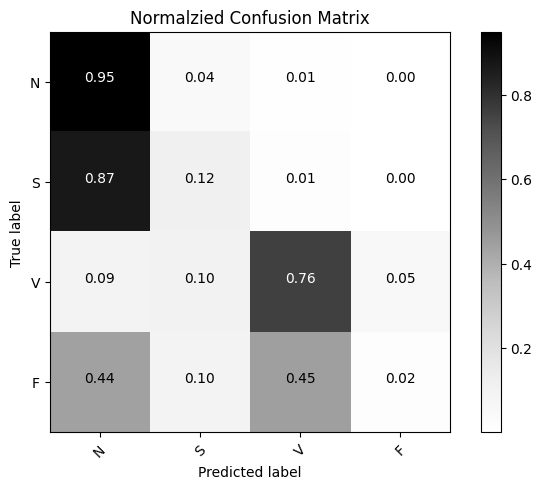

<Figure size 640x480 with 0 Axes>

In [14]:
import itertools

## display confusion matrix
display_labels = ['N', 'S', 'V', 'F']

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()
    plt.clf()
    
plot_confusion_matrix(c_matrix, display_labels ,
                      title='Normalzied Confusion Matrix', normalize=True, cmap='Greys')
